In [24]:
import pandas as pd
financial_df = pd.read_csv('/Users/alecxszhang/Desktop/Stat 359/data/Financial_tweets.csv')
politics_df = pd.read_csv("/Users/alecxszhang/Desktop/Stat 359/data/politics_sentiment.csv")
videogames_df = pd.read_csv("/Users/alecxszhang/Desktop/Stat 359/data/videogames_train.csv")
nfl_df = pd.read_csv("/Users/alecxszhang/Desktop/Stat 359/data/nfl_sentiments.csv")
sentiment_df = pd.read_csv(
    "/Users/alecxszhang/Desktop/Stat 359/data/training.1600000.processed.noemoticon.csv",
    encoding='latin-1',
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text'],
    usecols=['sentiment', 'text']
)


In [25]:
def classify_sentiment(score):
    if score < -0.1:
        return 'negative'
    elif score > 0.1:
        return 'positive'
    else:
        return 'neutral'

financial_df['sentiment'] = financial_df['score'].apply(classify_sentiment)
financial_df['domain'] = 'financial'
financial_df = financial_df.rename(columns={'full_text': 'text'})


In [26]:
videogames_df['sentiment'] = videogames_df['sentiment'].str.lower()
videogames_df['domain'] = 'videogames'

In [27]:
videogames_df.head()

,id,topic,sentiment,text,domain
0,7871,MaddenNFL,negative,The speed this year is horrendous. @ EAMaddenNFL,videogames
1,1257,Battlefield,positive,. Phantom Bow + Suppressed Deagle - Battlefiel...,videogames
2,12597,WorldOfCraft,neutral,Check out this item I just got! along With the...,videogames
3,3107,Dota2,neutral,ARTEEZY Fast Game No Mercy played with his Sup...,videogames
4,544,ApexLegends,neutral,I'm consistently getting top 5 in,videogames


In [28]:
financial_df.head()


,id,created_at,text,score,sentiment,domain
0,1,2020-04-09 23:59:51+00:00,@KennyDegu very very little volume. With $10T ...,-0.7,negative,financial
1,2,2020-04-09 23:58:55+00:00,#ES_F achieved Target 2780 closing above 50% #...,0.0,neutral,financial
2,3,2020-04-09 23:58:52+00:00,RT @KimbleCharting: Silver/Gold indicator crea...,-0.2,negative,financial
3,4,2020-04-09 23:58:27+00:00,@Issaquahfunds Hedged our $MSFT position into ...,-0.4,negative,financial
4,5,2020-04-09 23:57:59+00:00,RT @zipillinois: 3 Surprisingly Controversial ...,0.1,positive,financial


In [29]:
politics_df['domain'] = 'politics'
politics_df = politics_df.rename(columns={'tweet': 'text'})
politics_df['sentiment'] = politics_df['sentiment'].map({0: 'negative', 1: 'positive', 2: 'neutral'})
politics_df.head()

,Unnamed: 0,text,sentiment,domain
0,192,@goodlaura What about Reese dying on #TTSC? An...,negative,politics
1,445,Nasty budget due and my iphone is being sent t...,negative,politics
2,1085,@transbay &quot;SFMTA Budget Proposal Hearing:...,negative,politics
3,1988,"Obama is visiting istanbul today, therefore al...",negative,politics
4,2019,just got back from the funeral of a government...,negative,politics


In [30]:

nfl_df['domain'] = 'nfl'

#filter to only tweets that mention NFL-related keywords
# to remove off-topic scraped content
import re
nfl_keywords = r'\b(nfl|football|touchdown|quarterback|qb|mahomes|brady|receiver|linebacker|' \
               r'packers|chiefs|eagles|cowboys|49ers|ravens|browns|patriots|bills|' \
               r'draft|super bowl|playoffs|offense|defense|interception|fumble|yard|'\
               r'rushing|passing|receiver|tight end|kicker)\b'

nfl_df = nfl_df[nfl_df['text'].str.contains(nfl_keywords, case=False, regex=True)]
print(f"NFL tweets after filtering: {len(nfl_df)}")

NFL tweets after filtering: 2823


/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_1962/3761376914.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  nfl_df = nfl_df[nfl_df['text'].str.contains(nfl_keywords, case=False, regex=True)]


In [31]:
combined_df = pd.concat([
    videogames_df[['text', 'sentiment', 'domain']],
    politics_df[['text', 'sentiment', 'domain']],
    financial_df[['text', 'sentiment', 'domain']],
    nfl_df[['text', 'sentiment', 'domain']]
], ignore_index=True)


combined_df.head()

,text,sentiment,domain
0,The speed this year is horrendous. @ EAMaddenNFL,negative,videogames
1,. Phantom Bow + Suppressed Deagle - Battlefiel...,positive,videogames
2,Check out this item I just got! along With the...,neutral,videogames
3,ARTEEZY Fast Game No Mercy played with his Sup...,neutral,videogames
4,I'm consistently getting top 5 in,neutral,videogames


In [32]:
min_count = combined_df['domain'].value_counts().min()
print(f"Balancing to {min_count} rows per domain")

combined_df = combined_df.groupby('domain').apply(
    lambda x: x.sample(min_count, random_state=42)
).reset_index(drop=True)

print(combined_df['domain'].value_counts())

Balancing to 2823 rows per domain
domain
financial     2823
nfl           2823
politics      2823
videogames    2823
Name: count, dtype: int64


/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_1962/4177230285.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df = combined_df.groupby('domain').apply(


In [33]:
min_count = combined_df['domain'].value_counts().min()
print(f"Balancing to {min_count} rows per domain")

combined_df = combined_df.groupby('domain').apply(
    lambda x: x.sample(min_count, random_state=42)
).reset_index(drop=True)

print(combined_df['domain'].value_counts())

none_samples = sentiment_df.sample(min_count, random_state=42)[['text', 'sentiment']].copy()
none_samples['domain'] = 'none'

# sentiment140 uses 0 and 4, remap to negative/positive
none_samples['sentiment'] = none_samples['sentiment'].map({0: 'negative', 4: 'positive'})

combined_df = pd.concat([
    combined_df,
    none_samples
], ignore_index=True)

combined_df['domain'].value_counts()

Balancing to 2823 rows per domain
domain
financial     2823
nfl           2823
politics      2823
videogames    2823
Name: count, dtype: int64


/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_1962/2324791408.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df = combined_df.groupby('domain').apply(


domain
financial     2823
nfl           2823
politics      2823
videogames    2823
none          2823
Name: count, dtype: int64

In [34]:
combined_df.to_csv('/Users/alecxszhang/Desktop/Stat 359/data/combined_df.csv', index=False)

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import evaluate

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# ── Label mappings ─────────────────────────────────────────────────────────────
domain2id    = {'nfl': 0, 'financial': 1, 'politics': 2, 'videogames': 3, 'none': 4}
id2domain    = {v: k for k, v in domain2id.items()}
sentiment2id = {'negative': 0, 'positive': 1}
id2sentiment = {v: k for k, v in sentiment2id.items()}

# ── Prep dataframe ─────────────────────────────────────────────────────────────
# If using Sentiment140 (0 = negative, 4 = positive), remap first:
# combined_df['sentiment'] = combined_df['sentiment'].map({0: 'negative', 4: 'positive'})

combined_df['domain_label']    = combined_df['domain'].map(domain2id)
combined_df['sentiment_label'] = combined_df['sentiment'].map(sentiment2id)
combined_df = combined_df.dropna(subset=['text', 'domain_label', 'sentiment_label'])
combined_df['text']            = combined_df['text'].astype(str)
combined_df['domain_label']    = combined_df['domain_label'].astype(int)
combined_df['sentiment_label'] = combined_df['sentiment_label'].astype(int)

train_df, val_df = train_test_split(
    combined_df[['text', 'domain_label', 'sentiment_label']],
    test_size=0.2,
    random_state=42,
    stratify=combined_df['domain_label']
)

# ── Tokenizer & datasets ───────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(examples):
    tokens = tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)
    tokens['labels']           = examples['domain_label']
    tokens['sentiment_labels'] = examples['sentiment_label']
    return tokens

train_ds = Dataset.from_pandas(train_df).map(tokenize, batched=True)
val_ds   = Dataset.from_pandas(val_df).map(tokenize, batched=True)

# ── Multi-task model ───────────────────────────────────────────────────────────
class MultiTaskModel(nn.Module):
    def __init__(self, backbone, num_domains, num_sentiments, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        hidden = backbone.config.hidden_size

        self.domain_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, num_domains)
        )
        self.sentiment_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, num_sentiments)
        )

    def forward(self, input_ids, attention_mask, labels=None, sentiment_labels=None):
        outputs   = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = outputs.last_hidden_state[:, 0, :]

        domain_logits    = self.domain_head(cls_token)
        sentiment_logits = self.sentiment_head(cls_token)

        loss = None
        if labels is not None and sentiment_labels is not None:
            domain_loss    = F.cross_entropy(domain_logits, labels)
            sentiment_loss = F.cross_entropy(sentiment_logits, sentiment_labels)
            loss           = domain_loss + sentiment_loss

        return {
            'loss':             loss,
            'domain_logits':    domain_logits,
            'sentiment_logits': sentiment_logits,
        }

backbone = AutoModel.from_pretrained('distilbert-base-uncased')
model    = MultiTaskModel(backbone, num_domains=5, num_sentiments=2).to(device)

# ── Custom Trainer ─────────────────────────────────────────────────────────────
class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        loss    = outputs['loss']
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)
        with torch.no_grad():
            outputs = model(**inputs)

        loss   = outputs['loss']
        logits = (outputs['domain_logits'], outputs['sentiment_logits'])
        labels = (inputs.get('labels'), inputs.get('sentiment_labels'))
        return loss, logits, labels

def compute_metrics(eval_pred):
    (domain_logits, sentiment_logits), (domain_labels, sentiment_labels) = eval_pred

    domain_preds    = np.argmax(domain_logits,    axis=-1)
    sentiment_preds = np.argmax(sentiment_logits, axis=-1)

    domain_acc    = (domain_preds    == domain_labels).mean()
    sentiment_acc = (sentiment_preds == sentiment_labels).mean()

    return {
        'domain_accuracy':    round(domain_acc, 4),
        'sentiment_accuracy': round(sentiment_acc, 4),
    }

# ── Training ───────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir='./multitask-classifier',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='domain_accuracy',
    report_to='none',
    logging_steps=10,
    fp16=torch.cuda.is_available(),
)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

# ── Save ───────────────────────────────────────────────────────────────────────
torch.save(model.state_dict(), './multitask-classifier/model_weights.pt')
tokenizer.save_pretrained('./multitask-classifier')
print("Saved to ./multitask-classifier")

Using device: mps


Map:   0%|          | 0/8648 [00:00<?, ? examples/s]

Map:   0%|          | 0/2162 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
print(combined_df['domain'].value_counts())
print(combined_df['domain'].unique())
print(combined_df['label'].isna().sum())
print(combined_df['label'].value_counts())

domain
financial     2823
nfl           2823
politics      2823
videogames    2823
none          2823
Name: count, dtype: int64
['financial' 'nfl' 'politics' 'videogames' 'none']
0
label
1    2823
0    2823
2    2823
3    2823
4    2823
Name: count, dtype: int64


In [ ]:
import torch.nn.functional as F

THRESHOLD = 0.15  # lowered threshold

def predict_domains(texts, model, tokenizer, threshold=THRESHOLD):
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        logits = model(**inputs).logits
    
    probs = F.softmax(logits, dim=-1)
    
    results = []
    for prob in probs:
        domains = [id2domain[i] for i, p in enumerate(prob) if p.item() > threshold]
        scores  = {id2domain[i]: round(p.item(), 3) for i, p in enumerate(prob)}
        
        # If nothing clears the threshold, return 'unknown'
        if not domains:
            domains = ['unknown']
        
        results.append({'domains': domains, 'scores': scores})
    
    return results

test_tweets = [
    "The NFL player just signed a huge financial deal",
    "Mahomes threw an interception",
    "NASDAQ dropped 3.5 points today",
    "I just had a great lunch today",
    "Congress passes new bill on healthcare reform"
]

predictions = predict_domains(test_tweets, model, tokenizer)
for tweet, pred in zip(test_tweets, predictions):
    print(f"Tweet: {tweet}")
    print(f"Domains: {pred['domains']}")
    print(f"Scores: {pred['scores']}\n")

Tweet: The NFL player just signed a huge financial deal
Domains: ['videogames']
Scores: {'nfl': 0.009, 'financial': 0.0, 'politics': 0.0, 'videogames': 0.989, 'none': 0.001}

Tweet: Mahomes threw an interception
Domains: ['nfl']
Scores: {'nfl': 0.999, 'financial': 0.0, 'politics': 0.0, 'videogames': 0.0, 'none': 0.0}

Tweet: NASDAQ dropped 3.5 points today
Domains: ['financial']
Scores: {'nfl': 0.0, 'financial': 0.996, 'politics': 0.001, 'videogames': 0.002, 'none': 0.001}

Tweet: I just had a great lunch today
Domains: ['none']
Scores: {'nfl': 0.0, 'financial': 0.0, 'politics': 0.0, 'videogames': 0.001, 'none': 0.999}

Tweet: Congress passes new bill on healthcare reform
Domains: ['politics']
Scores: {'nfl': 0.0, 'financial': 0.0, 'politics': 0.999, 'videogames': 0.0, 'none': 0.0}



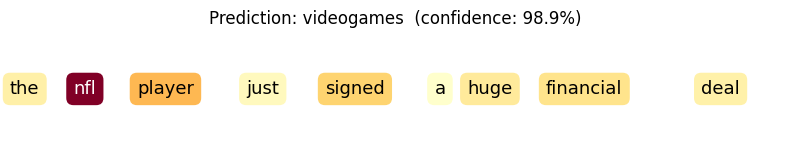

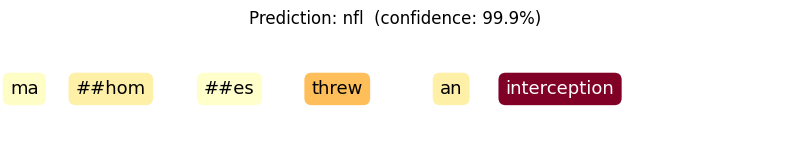

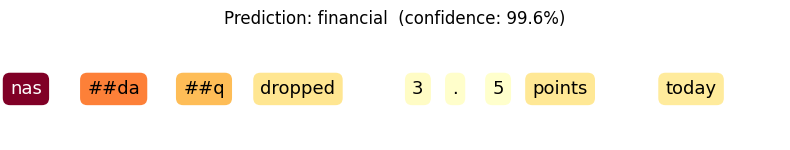

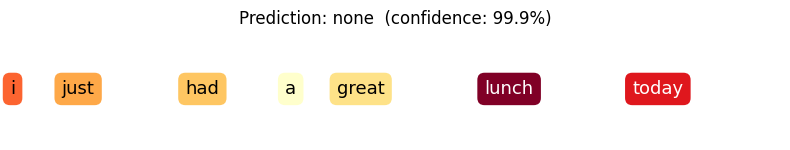

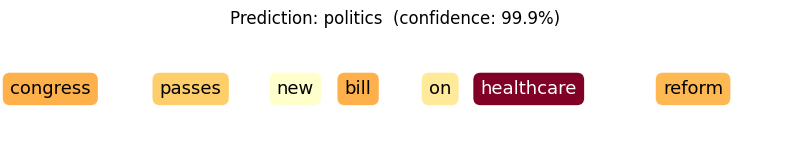

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
def get_saliency_domain(text, model, tokenizer, device):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)

    embedding_layer = model.distilbert.embeddings
    captured = {}

    def forward_hook(module, input, output):
        output.requires_grad_(True)
        output.retain_grad()
        captured['embeddings'] = output

    handle = embedding_layer.register_forward_hook(forward_hook)
    outputs = model(**inputs)
    handle.remove()

    predicted_class = outputs.logits.argmax(dim=-1).item()
    outputs.logits[0, predicted_class].backward()

    saliency = captured['embeddings'].grad[0].norm(dim=-1).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())
    label  = id2domain[predicted_class]  # only change from your original
    score  = torch.softmax(outputs.logits, dim=-1)[0, predicted_class].item()

    return tokens, saliency, label, score


def plot_saliency_domain(text, model, tokenizer, device):
    tokens, saliency, label, score = get_saliency_domain(text, model, tokenizer, device)

    tokens   = tokens[1:-1]
    saliency = saliency[1:-1]
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.6), 1.6))
    ax.axis('off')

    cmap = plt.get_cmap("YlOrRd")
    x = 0
    for token, sal in zip(tokens, saliency):
        color = cmap(sal)
        ax.text(x, 0.5, token, ha='left', va='center', fontsize=13,
                bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.4'),
                color='black' if sal < 0.7 else 'white')
        x += len(token) * 0.13 + 0.15

    ax.set_xlim(0, x)
    ax.set_ylim(0, 1)
    ax.set_title(f'Prediction: {label}  (confidence: {score:.1%})', fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()


# Run on your test tweets
test_tweets = [
    "The NFL player just signed a huge financial deal",
    "Mahomes threw an interception",
    "NASDAQ dropped 3.5 points today",
    "I just had a great lunch today",
    "Congress passes new bill on healthcare reform"
]

for tweet in test_tweets:
    plot_saliency_domain(tweet, model, tokenizer, device)

/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_17824/1696586452.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = combined_df.groupby('domain').apply(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


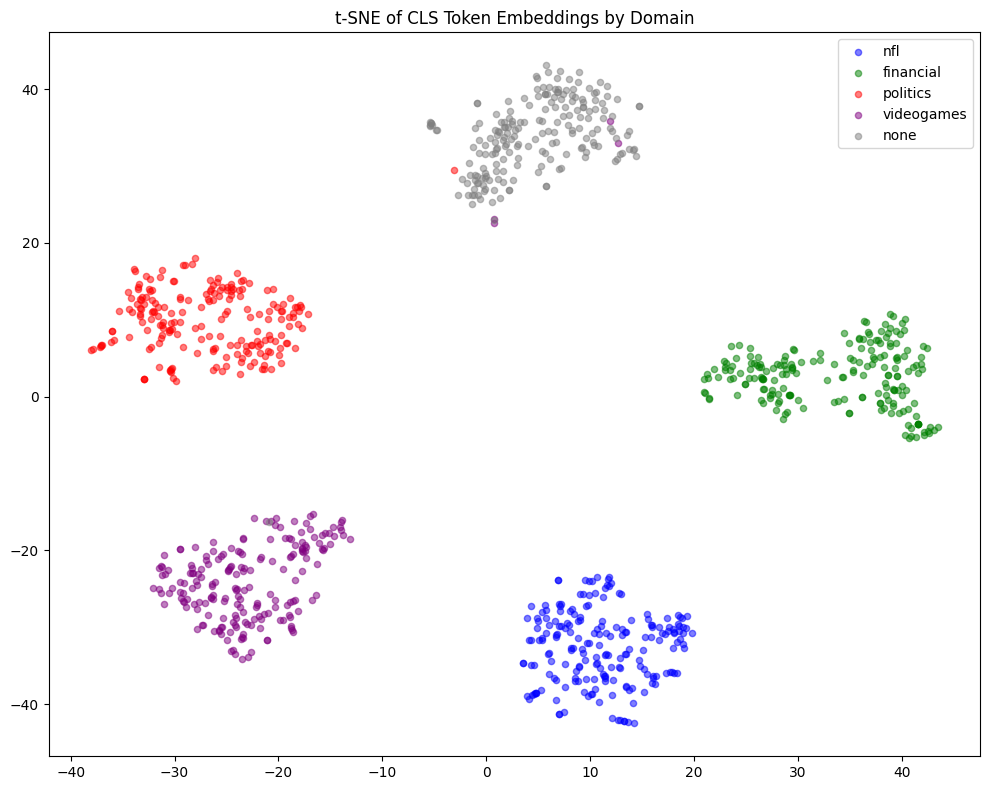

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def get_cls_embeddings(texts, model, tokenizer, device, batch_size=32):
    model.eval()
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors='pt', padding=True, 
                          truncation=True, max_length=128).to(device)
        
        with torch.no_grad():
            outputs = model.distilbert(**inputs)
            # CLS token is the first token
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(cls_embeddings.cpu().numpy())
    
    return np.vstack(all_embeddings)

# Sample some rows from each domain for visualization
sample_size = 200
sample_df = combined_df.groupby('domain').apply(
    lambda x: x.sample(min(sample_size, len(x)), random_state=42)
).reset_index(drop=True)

texts = sample_df['text'].tolist()
labels = sample_df['domain'].tolist()

# Extract embeddings
embeddings = get_cls_embeddings(texts, model, tokenizer, device)

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(embeddings)

# Plot
domain_colors = {
    'nfl': 'blue',
    'financial': 'green',
    'politics': 'red',
    'videogames': 'purple',
    'none': 'gray'
}

plt.figure(figsize=(10, 8))
for domain, color in domain_colors.items():
    mask = [l == domain for l in labels]
    pts = reduced[mask]
    plt.scatter(pts[:, 0], pts[:, 1], c=color, label=domain, alpha=0.5, s=20)

plt.legend()
plt.title('t-SNE of CLS Token Embeddings by Domain')
plt.tight_layout()
plt.show()

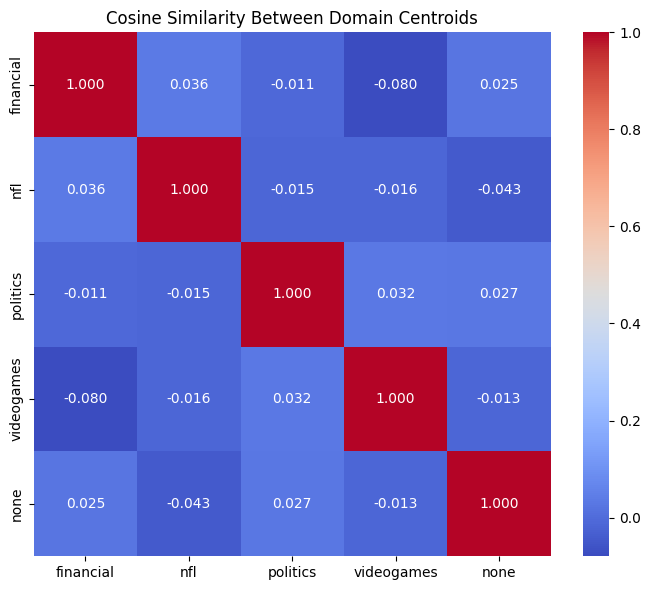

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute mean embedding per domain (the "class centroid")
domain_centroids = {}
for domain in combined_df['domain'].unique():
    mask = [l == domain for l in labels]
    domain_centroids[domain] = embeddings[mask].mean(axis=0)

# Cosine similarity matrix
domains = list(domain_centroids.keys())
centroid_matrix = np.vstack([domain_centroids[d] for d in domains])
sim_matrix = cosine_similarity(centroid_matrix)

# Plot as heatmap
import seaborn as sns
plt.figure(figsize=(7, 6))
sns.heatmap(sim_matrix, xticklabels=domains, yticklabels=domains, 
            annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Cosine Similarity Between Domain Centroids')
plt.tight_layout()
plt.show()


Processing 'interception'...
  'interception' tokenizes as: ['interception'], matching on root: 'interception'

Processing 'market'...
  'market' tokenizes as: ['market'], matching on root: 'market'

Processing 'draft'...
  'draft' tokenizes as: ['draft'], matching on root: 'draft'
    Tokens were: ['[CLS]', 'congress', 'drafted', 'a', 'new', 'healthcare', 'bill', '[SEP]']
    Tokens were: ['[CLS]', 'the', 'game', 'developer', 'drafted', 'new', 'patch', 'notes', '[SEP]']

Processing 'trade'...
  'trade' tokenizes as: ['trade'], matching on root: 'trade'
    Tokens were: ['[CLS]', 'the', 'madden', 'player', 'traded', 'his', 'star', 'quarterback', 'in', 'franchise', 'mode', '[SEP]']

=== Cosine similarity: same word, different contexts ===

  'interception' tokenizes as: ['interception'], matching on root: 'interception'
'interception':
  0.960  |  'Mahomes threw an interception in the fourth q' vs 'The cornerback made an interception at the go'  ✓ same domain
  0.716  |  'Mahomes threw

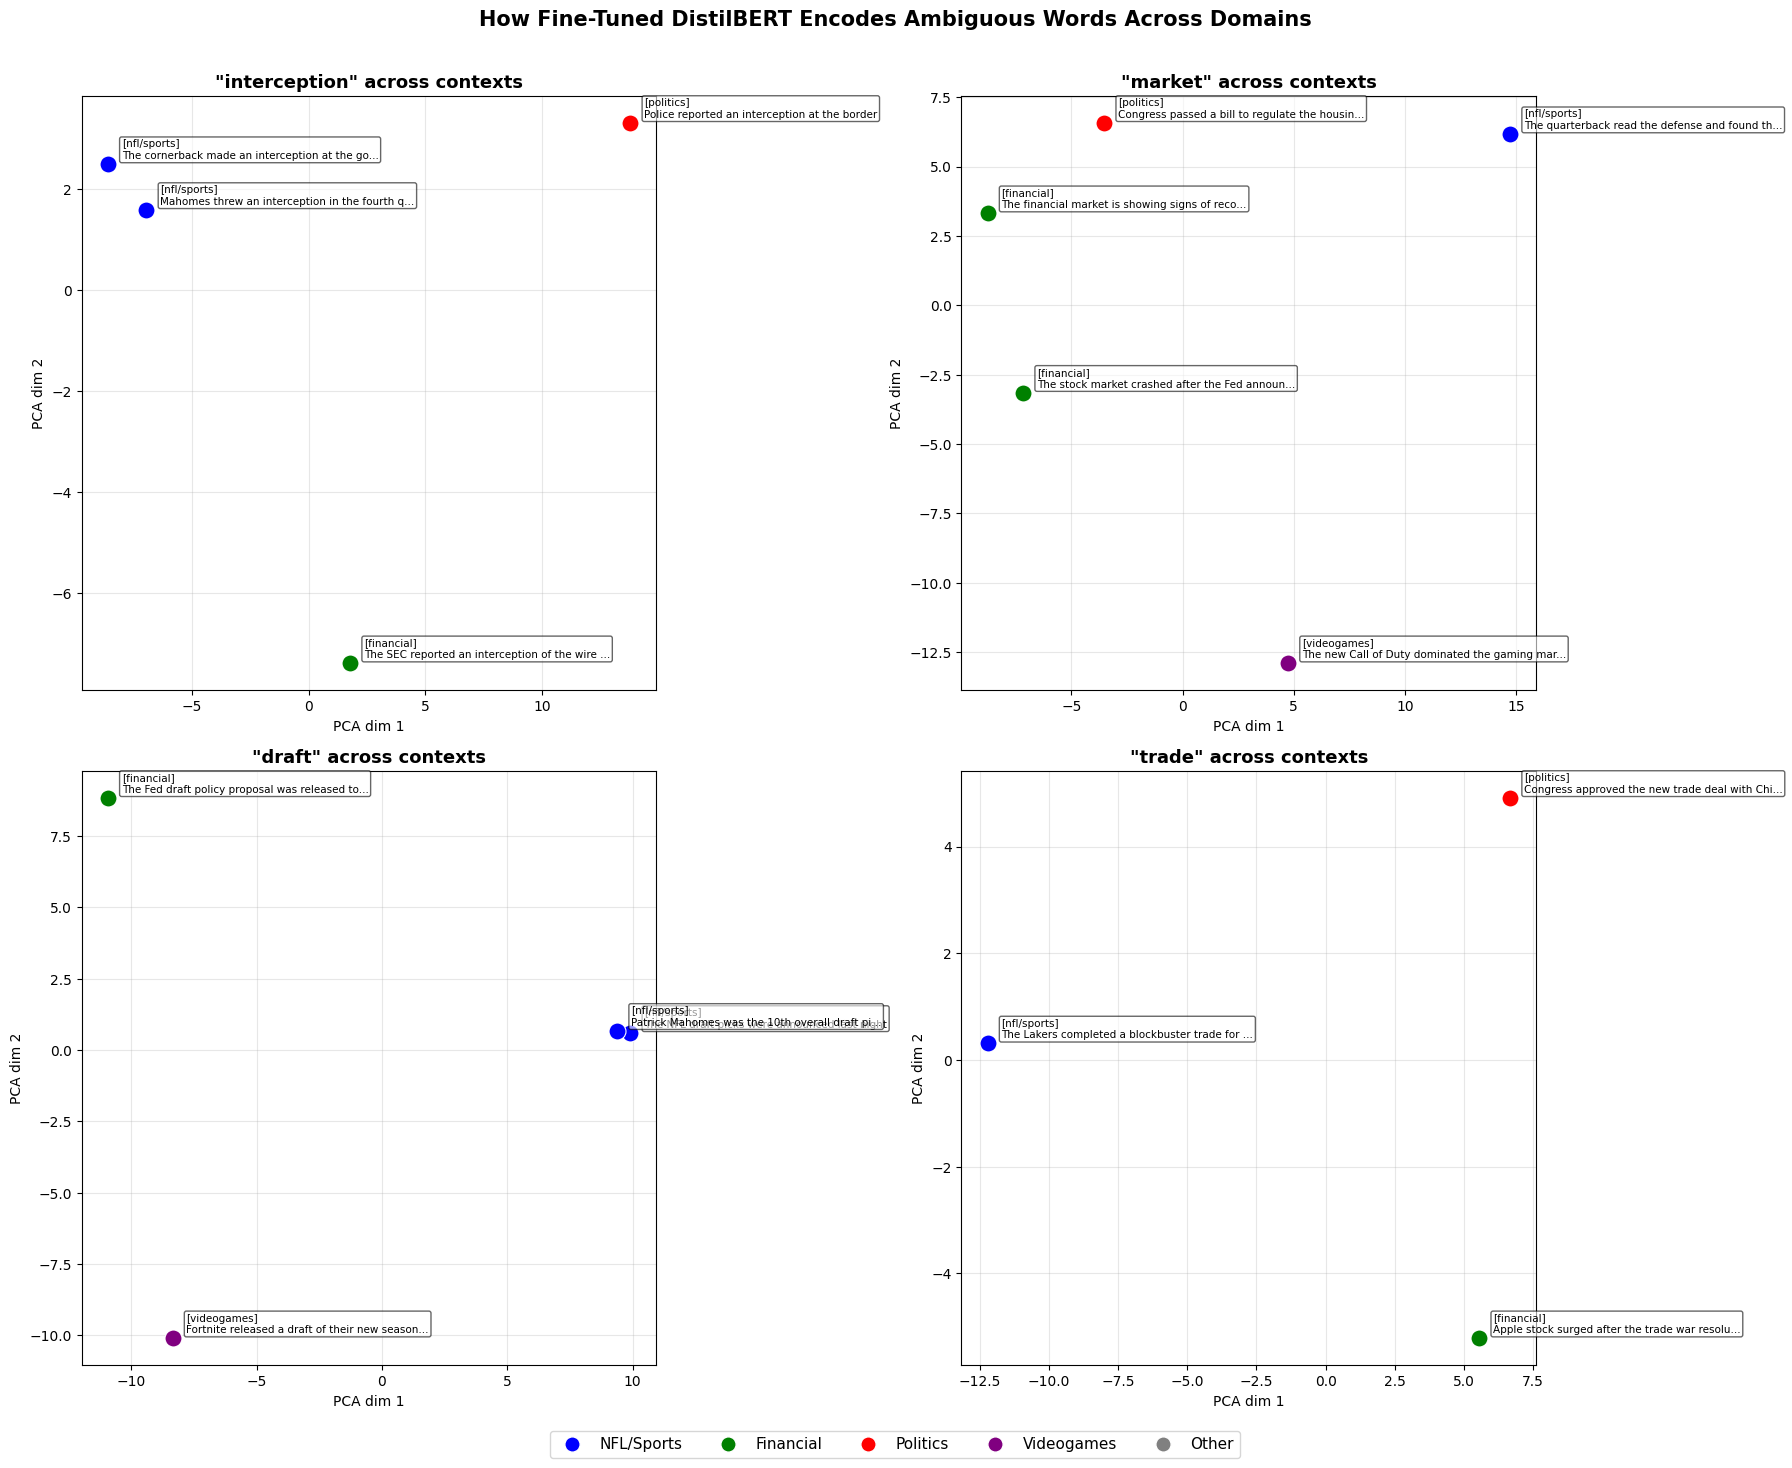

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.lines import Line2D

ambiguous_words = {
    'interception': [
        "Mahomes threw an interception in the fourth quarter",
        "The cornerback made an interception at the goal line",
        "The SEC reported an interception of the wire transfer",
        "Police reported an interception at the border",
    ],
    'market': [
        "The stock market crashed after the Fed announcement",
        "The financial market is showing signs of recovery",
        "The quarterback read the defense and found the open market",
        "The new Call of Duty dominated the gaming market",
        "Congress passed a bill to regulate the housing market",
    ],
    'draft': [
        "The NFL draft picks were announced last night",
        "Patrick Mahomes was the 10th overall draft pick",
        "The Fed draft policy proposal was released today",
        "Congress drafted a new healthcare bill",
        "The game developer drafted new patch notes",
        "Fortnite released a draft of their new season roadmap",
    ],
    'trade': [
        "The Lakers completed a blockbuster trade for the star player",
        "Congress approved the new trade deal with China",
        "Apple stock surged after the trade war resolution",
        "The Madden player traded his star quarterback in franchise mode",
    ]
}

def guess_domain(sentence):
    s = sentence.lower()
    if any(w in s for w in ['mahomes', 'nfl', 'quarterback', 'cornerback',
                              'draft pick', 'lakers', 'player']):
        return 'nfl/sports', 'blue'
    elif any(w in s for w in ['stock', 'fed', 'financial', 'market crash',
                               'trade war', 'apple stock', 'wire transfer']):
        return 'financial', 'green'
    elif any(w in s for w in ['congress', 'sec', 'bill', 'policy', 'police']):
        return 'politics', 'red'
    elif any(w in s for w in ['fortnite', 'call of duty', 'madden',
                               'gaming', 'game developer']):
        return 'videogames', 'purple'
    else:
        return 'other', 'gray'

def get_word_embedding_in_context(sentences, target_word, model, tokenizer, device):
    model.eval()
    embeddings = []
    found_sentences = []

    target_tokens = tokenizer.tokenize(target_word)
    root_token = target_tokens[0]
    print(f"  '{target_word}' tokenizes as: {target_tokens}, matching on root: '{root_token}'")

    for sentence in sentences:
        inputs = tokenizer(sentence, return_tensors='pt',
                          truncation=True, max_length=128).to(device)
        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

        target_indices = []
        i = 0
        while i < len(tokens):
            if tokens[i] == root_token:
                span = [i]
                j = i + 1
                while j < len(tokens) and tokens[j].startswith('##'):
                    span.append(j)
                    j += 1
                target_indices = span
                break
            i += 1

        if not target_indices:
            print(f"  Warning: root token '{root_token}' not found in: '{sentence}'")
            print(f"    Tokens were: {tokens}")
            continue

        with torch.no_grad():
            outputs = model.distilbert(**inputs)
            hidden_states = outputs.last_hidden_state[0]
            word_embedding = hidden_states[target_indices].mean(dim=0).cpu().numpy()
            embeddings.append(word_embedding)
            found_sentences.append(sentence)

    return np.array(embeddings), found_sentences


# ── Plots ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (word, sentences) in enumerate(ambiguous_words.items()):
    print(f"\nProcessing '{word}'...")
    embeddings, valid_sentences = get_word_embedding_in_context(
        sentences, word, model, tokenizer, device
    )

    if len(embeddings) < 3:
        print(f"  Not enough embeddings for '{word}', skipping")
        continue

    reduced = PCA(n_components=2).fit_transform(embeddings)

    ax = axes[idx]
    for i, (sentence, point) in enumerate(zip(valid_sentences, reduced)):
        domain_label, color = guess_domain(sentence)
        ax.scatter(point[0], point[1], c=color, s=150, zorder=3, edgecolors='white', linewidths=0.8)
        short = sentence[:45] + '...' if len(sentence) > 45 else sentence
        ax.annotate(
            f'[{domain_label}]\n{short}',
            (point[0], point[1]),
            fontsize=7.5,
            xytext=(10, 4),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6)
        )

    ax.set_title(f'"{word}" across contexts', fontsize=13, fontweight='bold')
    ax.set_xlabel('PCA dim 1', fontsize=10)
    ax.set_ylabel('PCA dim 2', fontsize=10)
    ax.grid(True, alpha=0.3)


# ── Cosine similarity tables below each plot ───────────────────────────────────

print("\n=== Cosine similarity: same word, different contexts ===\n")
for word, sentences in ambiguous_words.items():
    embeddings, valid_sentences = get_word_embedding_in_context(
        sentences, word, model, tokenizer, device
    )
    if len(embeddings) < 2:
        continue
    sim_matrix = cosine_similarity(embeddings)
    print(f"'{word}':")
    for i in range(len(valid_sentences)):
        for j in range(i + 1, len(valid_sentences)):
            short_i = valid_sentences[i][:45]
            short_j = valid_sentences[j][:45]
            sim = sim_matrix[i, j]
            # flag pairs that are surprisingly similar or dissimilar
            tag = '  ✓ same domain' if guess_domain(valid_sentences[i])[0] == guess_domain(valid_sentences[j])[0] else ''
            print(f"  {sim:.3f}  |  '{short_i}' vs '{short_j}'{tag}")
    print()


# ── Shared legend ──────────────────────────────────────────────────────────────

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',   markersize=11, label='NFL/Sports'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green',  markersize=11, label='Financial'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=11, label='Politics'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', markersize=11, label='Videogames'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',   markersize=11, label='Other'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle(
    'How Fine-Tuned DistilBERT Encodes Ambiguous Words Across Domains',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


Processing 'interception'...
  'interception' tokenizes as: ['interception'], matching on root: 'interception'


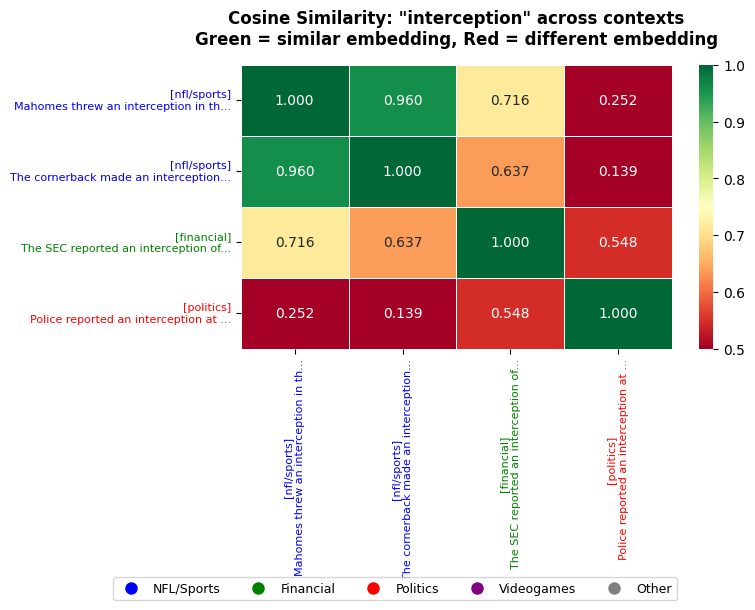


Processing 'market'...
  'market' tokenizes as: ['market'], matching on root: 'market'


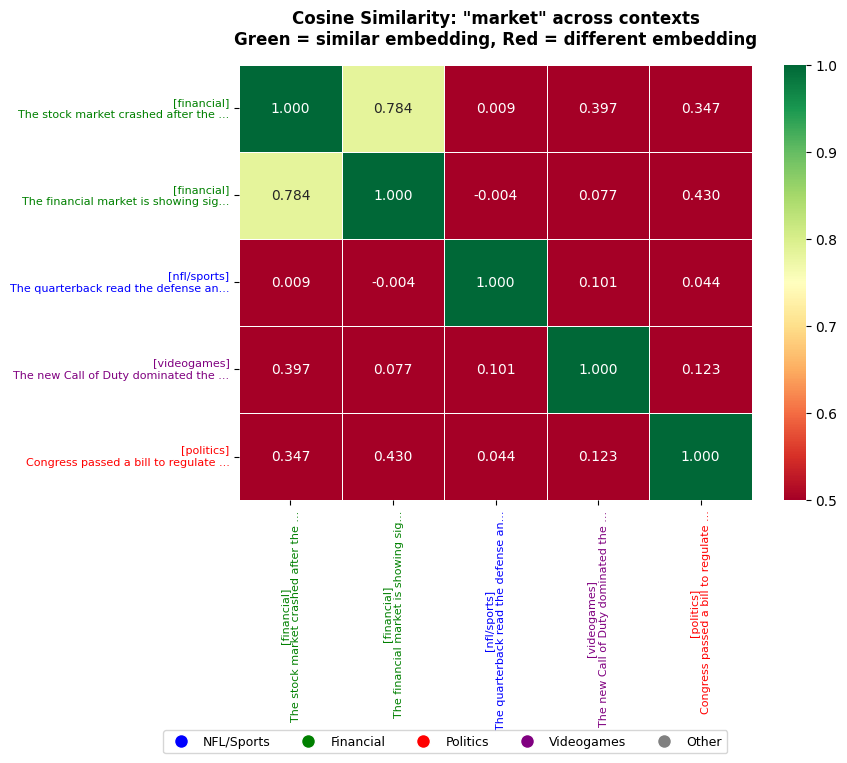


Processing 'draft'...
  'draft' tokenizes as: ['draft'], matching on root: 'draft'
    Tokens were: ['[CLS]', 'congress', 'drafted', 'a', 'new', 'healthcare', 'bill', '[SEP]']
    Tokens were: ['[CLS]', 'the', 'game', 'developer', 'drafted', 'new', 'patch', 'notes', '[SEP]']


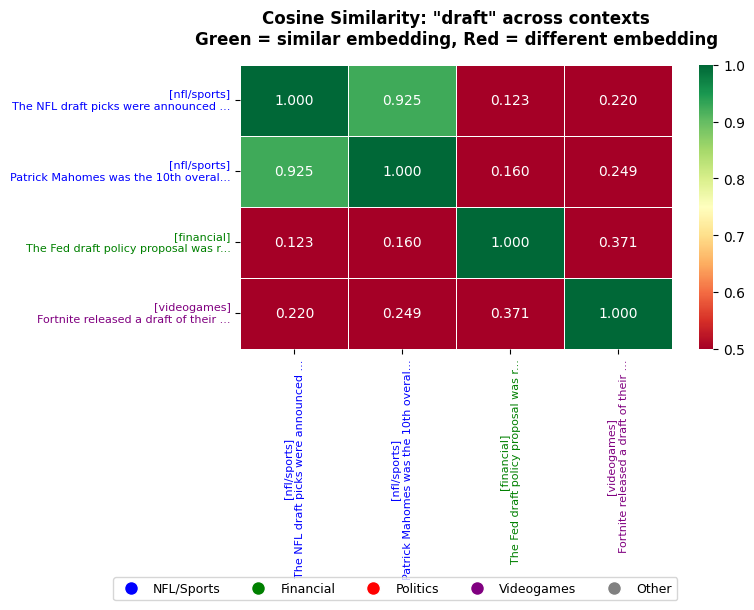


Processing 'trade'...
  'trade' tokenizes as: ['trade'], matching on root: 'trade'
    Tokens were: ['[CLS]', 'the', 'madden', 'player', 'traded', 'his', 'star', 'quarterback', 'in', 'franchise', 'mode', '[SEP]']


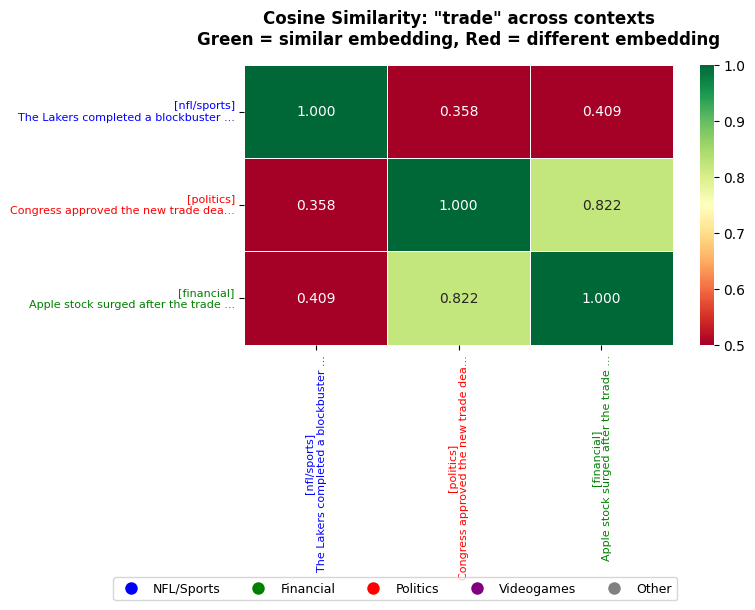

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

def plot_cosine_heatmap(word, sentences, model, tokenizer, device):
    embeddings, valid_sentences = get_word_embedding_in_context(
        sentences, word, model, tokenizer, device
    )

    if len(embeddings) < 2:
        print(f"Not enough embeddings for '{word}', skipping")
        return

    sim_matrix = cosine_similarity(embeddings)

    # Short labels: domain tag + truncated sentence
    labels = []
    for s in valid_sentences:
        domain_label, _ = guess_domain(s)
        short = s[:35] + '...' if len(s) > 35 else s
        labels.append(f"[{domain_label}]\n{short}")

    # Color the tick labels by domain
    domain_colors = {
        'nfl/sports': 'blue',
        'financial':  'green',
        'politics':   'red',
        'videogames': 'purple',
        'other':      'gray',
    }

    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 1.8), max(6, len(labels) * 1.5)))

    sns.heatmap(
        sim_matrix,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',       # red = dissimilar, green = similar
        vmin=0.5, vmax=1.0,  # cosine sims between contextualized embeddings are usually high
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        annot_kws={'size': 10}
    )

    # Color each tick label by its domain
    for tick, sentence in zip(ax.get_xticklabels(), valid_sentences):
        domain_label, color = guess_domain(sentence)
        tick.set_color(color)
        tick.set_fontsize(8)

    for tick, sentence in zip(ax.get_yticklabels(), valid_sentences):
        domain_label, color = guess_domain(sentence)
        tick.set_color(color)
        tick.set_fontsize(8)

    ax.set_title(
        f'Cosine Similarity: "{word}" across contexts\n'
        f'Green = similar embedding, Red = different embedding',
        fontsize=12, fontweight='bold', pad=15
    )

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',   markersize=10, label='NFL/Sports'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green',  markersize=10, label='Financial'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=10, label='Politics'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', markersize=10, label='Videogames'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',   markersize=10, label='Other'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=5,
               fontsize=9, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()


# Run for all words
for word, sentences in ambiguous_words.items():
    print(f"\nProcessing '{word}'...")
    plot_cosine_heatmap(word, sentences, model, tokenizer, device)

In [ ]:
import pandas as pd
import torch.nn.functional as F

def batch_predict_domains(texts, model, tokenizer, device, threshold=0.05, batch_size=64):
    model.eval()
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            logits = model(**inputs).logits
            probs = F.softmax(logits, dim=-1).cpu().numpy()

        all_probs.append(probs)

        # Progress indicator
        if (i // batch_size) % 20 == 0:
            print(f"  Processed {min(i + batch_size, len(texts)):,} / {len(texts):,}", end='\r')

    print(f"  Done — processed {len(texts):,} texts")
    return np.vstack(all_probs)


# ── Sample 100k from combined_df (or whatever big dataset you want) ────────────

SAMPLE_SIZE = 100_000
THRESHOLD   = 0.05

# Sample from sentiment_df instead — it has 'sentiment' and 'text' columns
# (no 'domain' column since it's unlabeled data)
sample = sentiment_df.sample(min(SAMPLE_SIZE, len(sentiment_df)), random_state=42).reset_index(drop=True)
texts  = sample['text'].astype(str).tolist()

print(f"Running inference on {len(texts):,} texts...")
probs = batch_predict_domains(texts, model, tokenizer, device, threshold=THRESHOLD)

# ── Build results dataframe ────────────────────────────────────────────────────

domains = list(domain2id.keys())

results_df = pd.DataFrame({
    'text':      sample['text'].values,
    'sentiment': sample['sentiment'].values,   # keep the sentiment140 label (0/4)
})

# One probability column + one binary threshold column per domain
for domain, idx in domain2id.items():
    results_df[f'prob_{domain}']  = probs[:, idx].round(4)
    results_df[f'flag_{domain}']  = (probs[:, idx] >= THRESHOLD).astype(int)

# Top predicted label (argmax) and its confidence
results_df['pred_label']      = [domains[i] for i in probs.argmax(axis=1)]
results_df['pred_confidence'] = probs.max(axis=1).round(4)

# How many domain flags fired per text
flag_cols = [f'flag_{d}' for d in domains]
results_df['n_flags'] = results_df[flag_cols].sum(axis=1)

print(results_df.head(10).to_string())
print(f"\nShape: {results_df.shape}")

# ── Quick summary ──────────────────────────────────────────────────────────────

print("\n=== Predicted label distribution ===")
print(results_df['pred_label'].value_counts())

print("\n=== Flag rate per domain (% of texts above threshold) ===")
for d in domains:
    rate = results_df[f'flag_{d}'].mean() * 100
    print(f"  {d:<12}  {rate:.1f}%")

print("\n=== Texts flagged for multiple domains ===")
print(results_df['n_flags'].value_counts().sort_index())

Running inference on 100,000 texts...
  Done — processed 100,000 texts
                                                                                                                                        text  sentiment  prob_nfl  flag_nfl  prob_financial  flag_financial  prob_politics  flag_politics  prob_videogames  flag_videogames  prob_none  flag_none pred_label  pred_confidence  n_flags
0                                                                                                     @chrishasboobs AHHH I HOPE YOUR OK!!!           0       0.0         0          0.0000               0         0.0001              0           0.0008                0     0.9990          1       none           0.9990        1
1                                                                                  @misstoriblack cool , i have no tweet apps  for my razr 2          0       0.0         0          0.0000               0         0.0001              0           0.0009                0     0.9

In [ ]:
multi_flag = results_df[results_df['n_flags'] > 1].copy()

print(f"Total multi-flag rows: {len(multi_flag):,} ({len(multi_flag)/len(results_df)*100:.1f}% of sample)\n")

prob_cols = [f'prob_{d}' for d in domains]
flag_cols = [f'flag_{d}' for d in domains]

def flags_fired(row):
    return ' + '.join([d for d in domains if row[f'flag_{d}'] == 1])

multi_flag['flags_fired'] = multi_flag.apply(flags_fired, axis=1)

print("=== Flag combination counts ===")
print(multi_flag['flags_fired'].value_counts().to_string())
print()

print("=== Examples per combination ===\n")
for combo, group in multi_flag.groupby('flags_fired'):
    print(f"── {combo} ({len(group):,} rows) ──")
    sample = group[['text', 'sentiment', 'pred_label'] + prob_cols].head(5)
    for _, row in sample.iterrows():
        print(f"  text       : {row['text'][:100]}")
        print(f"  sentiment  : {'positive' if row['sentiment'] == 4 else 'negative'}")
        print(f"  pred_label : {row['pred_label']}")
        print(f"  probs      : " + "  ".join([f"{d}={row[f'prob_{d}']:.3f}" for d in domains]))
        print()

Total multi-flag rows: 3,522 (3.5% of sample)

=== Flag combination counts ===
flags_fired
videogames + none                     3116
financial + none                       142
politics + none                        104
nfl + none                              66
nfl + videogames + none                 34
politics + videogames + none            21
financial + videogames + none           11
nfl + videogames                         9
politics + videogames                    5
financial + videogames                   5
financial + politics + none              4
nfl + politics + none                    3
financial + politics                     1
nfl + politics + videogames + none       1

=== Examples per combination ===

── financial + none (142 rows) ──
  text       : lots of cool ppl  ~~&gt; @actionchick @thewildjoker @walterdoc @JGDemas @amilya @williger  #followfr
  sentiment  : positive
  pred_label : none
  probs      : nfl=0.000  financial=0.058  politics=0.000  videogames=0.013  n

In [ ]:
# Pick whichever combo you want to inspect
combos_to_check = [
    'nfl + videogames + none']

for combo in combos_to_check:
    subset = multi_flag[multi_flag['flags_fired'] == combo]
    print(f"\n{'='*60}")
    print(f"  {combo} ({len(subset)} rows)")
    print(f"{'='*60}")
    for _, row in subset.iterrows():
        print(f"  text      : {row['text']}")
        print(f"  sentiment : {'positive' if row['sentiment'] == 4 else 'negative'}")
        print(f"  probs     : " + "  ".join([f"{d}={row[f'prob_{d}']:.3f}" for d in domains]))
        print()


  nfl + videogames + none (34 rows)
  text      : The Yankees killed the Rangers again!! I love it! That makes it even better 
  sentiment : positive
  probs     : nfl=0.061  financial=0.002  politics=0.017  videogames=0.059  none=0.861

  text      : 22 days until the NBA Draft still 
  sentiment : negative
  probs     : nfl=0.378  financial=0.002  politics=0.010  videogames=0.502  none=0.108

  text      : Liverpool beat hammers to go to top of the league.. for what might be the last time this seadon 
  sentiment : negative
  probs     : nfl=0.071  financial=0.002  politics=0.019  videogames=0.748  none=0.160

  text      : come on bombers 
  sentiment : negative
  probs     : nfl=0.325  financial=0.002  politics=0.008  videogames=0.058  none=0.607

  text      : next up: the 09 nba draft 
  sentiment : positive
  probs     : nfl=0.125  financial=0.001  politics=0.007  videogames=0.787  none=0.081

  text      : Not to worry...I'll behave. Wouldn't want Twitter to put me in the pena

In [ ]:
# Pick whichever combo you want to inspect
combos_to_check = [
    'financial + politics + none']

for combo in combos_to_check:
    subset = multi_flag[multi_flag['flags_fired'] == combo]
    print(f"\n{'='*60}")
    print(f"  {combo} ({len(subset)} rows)")
    print(f"{'='*60}")
    for _, row in subset.iterrows():
        print(f"  text      : {row['text']}")
        print(f"  sentiment : {'positive' if row['sentiment'] == 4 else 'negative'}")
        print(f"  probs     : " + "  ".join([f"{d}={row[f'prob_{d}']:.3f}" for d in domains]))
        print()


  financial + politics + none (4 rows)
  text      : time for balance sheets and income statements 
  sentiment : negative
  probs     : nfl=0.002  financial=0.230  politics=0.635  videogames=0.014  none=0.119

  text      : @2xtdg it will be worth it  then you can go to town on the spending after lol
  sentiment : positive
  probs     : nfl=0.001  financial=0.323  politics=0.209  videogames=0.031  none=0.436

  text      : Cool, my funds are only down by 12% in total now. Not long ago they were -30% down. Is the economy getting better? 
  sentiment : positive
  probs     : nfl=0.001  financial=0.058  politics=0.235  videogames=0.010  none=0.696

  text      : same same, but different (lesesal) nothing to look at, just words in my economic papers 
  sentiment : negative
  probs     : nfl=0.001  financial=0.051  politics=0.866  videogames=0.016  none=0.065



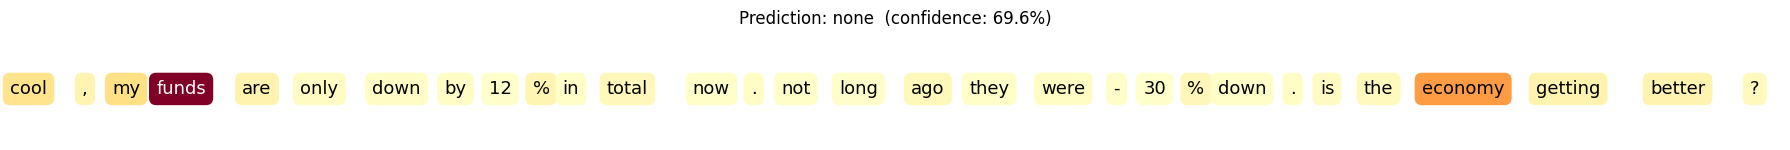

In [ ]:
plot_saliency_domain(
    "Cool, my funds are only down by 12% in total now. Not long ago they were -30% down. Is the economy getting better?",
    model, tokenizer, device
)